# NIFTY Options Backtest
**Strategy**: Top 3 Bearish + Top 3 Bullish signal combinations from historical analysis  
**Options**: 1-strike OTM weekly puts/calls  
**Pricing**: Black-Scholes with India VIX as IV  
**Exit**: Stop-loss OR profit target OR 10:15 AM hard exit  

> All configurable variables are in Cell 1. Change them and re-run.

In [19]:
# ── Cell 1: Configuration — all variables are here ────────────────────────────
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import date, timedelta, datetime
from datetime import time as dtime
from scipy.stats import norm as _norm
import warnings
warnings.filterwarnings('ignore')

# ── trade parameters ──────────────────────────────────────────────
STOP_LOSS_PCT      = 0.40    # Exit if option loses this % of entry premium
PROFIT_TARGET_PCT  = 0.40    # Exit if option gains this % of entry premium
LOT_SIZE           = 75      # NIFTY lot size
STRIKE_STEP        = 50      # NIFTY strike interval (points)
STRIKES_OTM        = 1       # 1 = one strike OTM
RISK_FREE_RATE     = 0.065   # Annual risk-free rate
BROKERAGE          = 80      # Rs round-trip per lot (Zerodha + STT + charges)
STARTING_CAPITAL   = 10_000  # Rs starting capital for compounded simulation
BACKTEST_DAYS      = 1 * 365      # Most recent trading days to backtest
BASE_RATE          = 54.5    # Historical NIFTY first-hour DOWN rate (%)

# ── paths ─────────────────────────────────────────────────────────
_cwd = Path.cwd()
BASE = _cwd if (_cwd / 'v2' / 'v2_aligned_dataset.csv').exists() else _cwd.parent
ALIGNED_CSV  = BASE / 'v2' / 'v2_aligned_dataset.csv'
MINUTE_CACHE = BASE / 'v2' / 'kite_minute_cache'
SIGNALS_CSV  = BASE / 'v2' / 'v2_reliable_signals.csv'
OUT_DIR      = Path.cwd()

print('Config loaded.')
print(f'  Project base  : {BASE}')
print(f'  Stop loss     : -{STOP_LOSS_PCT:.0%} of premium')
print(f'  Profit target : +{PROFIT_TARGET_PCT:.0%} of premium')
print(f'  Lot size      : {LOT_SIZE}')
print(f'  Brokerage     : Rs{BROKERAGE}/lot round-trip')

Config loaded.
  Project base  : c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research
  Stop loss     : -40% of premium
  Profit target : +40% of premium
  Lot size      : 75
  Brokerage     : Rs80/lot round-trip


In [20]:
# ── Cell 2: Load aligned dataset + define top-3 bear/bull signals ──────────────
aligned = pd.read_csv(ALIGNED_CSV, parse_dates=['india_date'])
aligned = aligned.sort_values('india_date').reset_index(drop=True)
aligned['VIX_INDIA_level'] = aligned['VIX_INDIA_level'].ffill().bfill()

# Last N trading days
backtest_df = aligned.tail(BACKTEST_DAYS).copy().reset_index(drop=True)
start_date  = backtest_df['india_date'].iloc[0].date()
end_date    = backtest_df['india_date'].iloc[-1].date()
print(f'Backtest period : {start_date}  to  {end_date}')
print(f'Trading days    : {len(backtest_df)}')

# Load reliable signal combinations
reliable = pd.read_csv(SIGNALS_CSV)

# Top 3 BEARISH: highest P_Down > base rate, sorted by edge descending
top_bearish = (reliable[reliable['P_Down'] > BASE_RATE]
               .sort_values('Edge', ascending=False)
               .head(3)
               .reset_index(drop=True))

# Top 3 BULLISH: lowest P_Down < (100 - base rate), sorted ascending
top_bullish = (reliable[reliable['P_Down'] < (100 - BASE_RATE)]
               .sort_values('P_Down', ascending=True)
               .head(3)
               .reset_index(drop=True))

print('\nTop 3 BEARISH signal combos:')
for _, r in top_bearish.iterrows():
    print(f'  [{int(r["Level"])}] {r["Signal"]:<55} P(DOWN)={r["P_Down"]:.1f}%  Edge=+{r["Edge"]:.1f}%  N={int(r["N"])}')

print('\nTop 3 BULLISH signal combos:')
for _, r in top_bullish.iterrows():
    print(f'  [{int(r["Level"])}] {r["Signal"]:<55} P(UP)={100-r["P_Down"]:.1f}%  Edge=+{abs(r["Edge"]):.1f}%  N={int(r["N"])}')

Backtest period : 2024-10-08  to  2026-03-30
Trading days    : 365

Top 3 BEARISH signal combos:
  [4] Gap Up + Prev India DOWN + US UP + SGX UP               P(DOWN)=73.8%  Edge=+19.3%  N=65
  [4] Gap Up + Prev India DOWN + SGX UP + DAX UP              P(DOWN)=73.1%  Edge=+18.5%  N=52
  [3] Gap Up + Prev India DOWN + SGX UP                       P(DOWN)=71.8%  Edge=+17.3%  N=71

Top 3 BULLISH signal combos:
  [2] Gap Down + US UP                                        P(UP)=76.2%  Edge=+30.7%  N=42
  [3] Prev India DOWN + US UP + SGX DOWN                      P(UP)=68.9%  Edge=+23.4%  N=45
  [2] Gap Down + SGX UP                                       P(UP)=65.9%  Edge=+20.4%  N=41


In [21]:
# ── Cell 3: Load NIFTY minute data from cache ──────────────────────────────────
all_chunks = []
for pkl_path in sorted(MINUTE_CACHE.glob('minute_256265_*.pkl')):
    with open(pkl_path, 'rb') as f:
        chunk = pickle.load(f)
    chunk.index = pd.to_datetime(chunk.index)
    # Ensure timezone aware (IST)
    if chunk.index.tzinfo is None:
        chunk.index = chunk.index.tz_localize('Asia/Kolkata')
    # Filter to backtest date range (with 1-day buffer each side)
    lo = pd.Timestamp(start_date) - pd.Timedelta(days=1)
    hi = pd.Timestamp(end_date)   + pd.Timedelta(days=1)
    mask = (chunk.index >= lo.tz_localize('Asia/Kolkata')) & \
           (chunk.index <= hi.tz_localize('Asia/Kolkata'))
    if mask.sum() > 0:
        all_chunks.append(chunk[mask])

if all_chunks:
    minute_all = pd.concat(all_chunks).sort_index()
    print(f'Minute data loaded : {len(minute_all):,} rows')
    print(f'Date range         : {minute_all.index[0].date()}  to  {minute_all.index[-1].date()}')
    print(f'Columns            : {list(minute_all.columns)}')
else:
    print('WARNING: No minute data found in cache for backtest range.')
    minute_all = pd.DataFrame()

Minute data loaded : 137,370 rows
Date range         : 2024-10-07  to  2026-03-30
Columns            : ['open', 'high', 'low', 'close', 'volume']


In [22]:
# ── Cell 4: Compute binary signals + classify each backtest day ─────────────────
GAP_THR   = 0.0015
GAP_LARGE = 0.0040

def compute_signals(row):
    return {
        'Gap Up'          : float(row['gap_pct']) >  GAP_THR,
        'Gap Up Strong'   : float(row['gap_pct']) >  GAP_LARGE,
        'Gap Down'        : float(row['gap_pct']) < -GAP_THR,
        'Prev India UP'   : float(row['prev_india_ret']) > 0,
        'Prev India DOWN' : float(row['prev_india_ret']) < 0,
        'US UP'           : float(row['SP500_ret']) > 0,
        'US DOWN'         : float(row['SP500_ret']) < 0,
        'SGX UP'          : float(row['SGX_ret']) > 0,
        'SGX DOWN'        : float(row['SGX_ret']) < 0,
        'DAX UP'          : float(row['DAX_ret']) > 0,
        'VIX Rising'      : float(row['VIX_US_ret']) > 0,
        'VIX Falling'     : float(row['VIX_US_ret']) < 0,
        'VIX Spike'       : float(row['VIX_US_ret']) > 0.05,
    }

def check_combo(signals, signal_str):
    return all(signals.get(s.strip(), False) for s in signal_str.split('+'))

bear_combos = list(top_bearish['Signal'])
bull_combos = list(top_bullish['Signal'])

trade_days = []
for _, row in backtest_df.iterrows():
    sigs = compute_signals(row)
    bear_fired = [c for c in bear_combos if check_combo(sigs, c)]
    bull_fired = [c for c in bull_combos if check_combo(sigs, c)]

    if bear_fired and bull_fired:
        action, combo_fired = 'CONFLICT', None
    elif bear_fired:
        action, combo_fired = 'BEARISH', bear_fired[0]
    elif bull_fired:
        action, combo_fired = 'BULLISH', bull_fired[0]
    else:
        action, combo_fired = 'NO_SIGNAL', None

    trade_days.append({
        'india_date'  : row['india_date'],
        'india_open'  : float(row['india_open']),
        'gap_pct'     : float(row['gap_pct']),
        'vix_india'   : float(row['VIX_INDIA_level']),
        'dir_60'      : int(row['dir_60']),
        'ret_60'      : float(row['ret_60']),
        'action'      : action,
        'combo_fired' : combo_fired,
    })

trade_days_df = pd.DataFrame(trade_days)

print('Signal distribution across backtest period:')
for k, v in trade_days_df['action'].value_counts().items():
    print(f'  {k:<12}: {v:>3} days  ({v/len(trade_days_df)*100:.1f}%)')
print(f'\nTrade-able days : {(trade_days_df["action"].isin(["BEARISH","BULLISH"])).sum()}')

Signal distribution across backtest period:
  NO_SIGNAL   : 277 days  (75.9%)
  BULLISH     :  53 days  (14.5%)
  BEARISH     :  35 days  (9.6%)

Trade-able days : 88


In [23]:
# ── Cell 5: Black-Scholes pricing + trade simulation function ──────────────────

def bs_price(S, K, T, r, sigma, opt_type='CE'):
    '''Black-Scholes price in index points. opt_type = CE or PE.'''
    if T <= 1e-7:
        return max(0.0, S - K) if opt_type == 'CE' else max(0.0, K - S)
    sq = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / sq
    d2 = d1 - sq
    if opt_type == 'CE':
        return float(S * _norm.cdf(d1) - K * np.exp(-r * T) * _norm.cdf(d2))
    return float(K * np.exp(-r * T) * _norm.cdf(-d2) - S * _norm.cdf(-d1))


def nearest_thursday(d):
    '''Nearest future Thursday. If d is Thursday, returns next Thursday.'''
    days = (3 - d.weekday()) % 7
    if days == 0:
        days = 7
    return d + timedelta(days=days)


def simulate_trade(trade_date, action, nifty_open, vix_india, minute_df):
    '''
    Simulate one options trade minute-by-minute using BS pricing.
    Returns dict with trade details + P&L, or None if degenerate.
    '''
    if isinstance(trade_date, pd.Timestamp):
        trade_date = trade_date.date()

    expiry = nearest_thursday(trade_date)
    dte    = (expiry - trade_date).days

    atm = round(nifty_open / STRIKE_STEP) * STRIKE_STEP
    if action == 'BEARISH':
        strike   = atm - STRIKE_STEP * STRIKES_OTM
        opt_type = 'PE'
    else:
        strike   = atm + STRIKE_STEP * STRIKES_OTM
        opt_type = 'CE'

    # IV: India VIX/100 with weekly-skew adjustment
    iv_raw = vix_india / 100.0
    iv     = iv_raw * (1.30 if dte <= 2 else 1.15 if dte <= 4 else 1.05)

    def tte(t_obj):
        '''Time to expiry in years from t_obj (time) on trade_date.'''
        expiry_dt  = datetime.combine(expiry, dtime(15, 30))
        current_dt = datetime.combine(trade_date, t_obj)
        secs = (expiry_dt - current_dt).total_seconds()
        return max(secs, 0.0) / (365.25 * 24 * 3600)

    # Entry at 9:15 using NIFTY open
    entry_price = bs_price(nifty_open, strike, tte(dtime(9, 20)), RISK_FREE_RATE, iv, opt_type)
    if entry_price < 0.5:
        return None   # degenerate option

    sl_price = entry_price * (1 - STOP_LOSS_PCT)
    tp_price = entry_price * (1 + PROFIT_TARGET_PCT)

    # Filter minute data to this trading date, 9:16-10:15
    day_min = minute_df[minute_df.index.date == trade_date]
    day_min = day_min.between_time('09:21', '10:15')

    exit_price  = None
    exit_reason = '10:15 exit'
    exit_time   = '10:15'

    for ts, m in day_min.iterrows():
        spot  = float(m['close'])
        t_now = ts.to_pydatetime().replace(tzinfo=None).time()
        price = bs_price(spot, strike, tte(t_now), RISK_FREE_RATE, iv, opt_type)

        if price <= sl_price:
            exit_price, exit_reason, exit_time = sl_price, 'Stop Loss', str(t_now)[:5]
            break
        if price >= tp_price:
            exit_price, exit_reason, exit_time = tp_price, 'Target Hit', str(t_now)[:5]
            break

    if exit_price is None:
        spot_last = float(day_min.iloc[-1]['close']) if len(day_min) > 0 else nifty_open
        exit_price = bs_price(spot_last, strike, tte(dtime(10, 15)), RISK_FREE_RATE, iv, opt_type)

    pnl_pts = exit_price - entry_price
    pnl_rs  = pnl_pts * LOT_SIZE - BROKERAGE

    return {
        'expiry'     : expiry,
        'dte'        : dte,
        'opt_type'   : opt_type,
        'strike'     : int(strike),
        'atm'        : int(atm),
        'iv_pct'     : round(iv * 100, 1),
        'entry_pts'  : round(entry_price, 2),
        'exit_pts'   : round(exit_price, 2),
        'exit_reason': exit_reason,
        'exit_time'  : exit_time,
        'pnl_pts'    : round(pnl_pts, 2),
        'pnl_rs'     : round(pnl_rs, 2),
    }

# Quick sanity check
_chk = bs_price(22000, 21950, 5/365, RISK_FREE_RATE, 0.15, 'PE')
print(f'BS sanity check: NIFTY=22000, 1-OTM PUT (21950), DTE=5, VIX=15% -> {_chk:.1f} pts')
print(f'  (Expected: ~100-150 pts for weekly OTM put)')

BS sanity check: NIFTY=22000, 1-OTM PUT (21950), DTE=5, VIX=15% -> 121.6 pts
  (Expected: ~100-150 pts for weekly OTM put)


In [24]:
# ── Cell 6: Run the 90-day backtest ────────────────────────────────────────────
tradeable = trade_days_df[trade_days_df['action'].isin(['BEARISH', 'BULLISH'])].copy()
print(f'Running backtest on {len(tradeable)} tradeable days...')

results = []
skipped = 0

for _, trow in tradeable.iterrows():
    res = simulate_trade(
        trade_date = trow['india_date'],
        action     = trow['action'],
        nifty_open = trow['india_open'],
        vix_india  = trow['vix_india'],
        minute_df  = minute_all,
    )
    if res is None:
        skipped += 1
        continue

    actual_dir = int(trow['dir_60'])
    pred_dir   = -1 if trow['action'] == 'BEARISH' else +1
    correct    = (pred_dir == actual_dir)

    results.append({
        'Date'        : trow['india_date'].date(),
        'Signal'      : trow['action'],
        'Combo'       : trow['combo_fired'],
        'NIFTY Open'  : int(round(trow['india_open'])),
        'Gap%'        : f"{trow['gap_pct']:+.2%}",
        'Strike'      : f"{res['strike']} {res['opt_type']}",
        'ATM'         : res['atm'],
        'DTE'         : res['dte'],
        'IV%'         : res['iv_pct'],
        'Entry (pts)' : res['entry_pts'],
        'Exit (pts)'  : res['exit_pts'],
        'Exit Reason' : res['exit_reason'],
        'Exit Time'   : res['exit_time'],
        'P&L (pts)'   : res['pnl_pts'],
        'P&L (Rs)'    : res['pnl_rs'],
        'Actual'      : 'DOWN' if actual_dir == -1 else 'UP',
        'Actual Ret%' : f"{trow['ret_60']:+.2%}",
        'Correct?'    : 'YES' if correct else 'NO',
    })

results_df = pd.DataFrame(results)

print(f'Done. Trades simulated : {len(results_df)}')
if skipped:
    print(f'Skipped (degenerate)   : {skipped}')
if len(results_df) > 0:
    wins = (results_df['P&L (Rs)'] > 0).sum()
    pnl  = results_df['P&L (Rs)'].sum()
    print(f'Wins / Losses          : {wins} / {len(results_df)-wins}')
    print(f'Total P&L              : Rs{pnl:,.0f}')

Running backtest on 88 tradeable days...
Done. Trades simulated : 88
Wins / Losses          : 54 / 34
Total P&L              : Rs81,904


In [25]:
# ── Cell 7: Trade log table ─────────────────────────────────────────────────────
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 220)

if len(results_df) == 0:
    print('No trades to display.')
else:
    display_cols = [
        'Date', 'Signal', 'NIFTY Open', 'Gap%', 'Strike', 'DTE', 'IV%',
        'Entry (pts)', 'Exit (pts)', 'Exit Reason', 'Exit Time',
        'P&L (pts)', 'P&L (Rs)', 'Actual', 'Actual Ret%', 'Correct?'
    ]
    log = results_df[display_cols].copy()

    sep = '=' * 200
    h1  = 'NIFTY OPTIONS BACKTEST — FULL TRADE LOG'
    h2  = f'SL={STOP_LOSS_PCT:.0%} premium  |  Target={PROFIT_TARGET_PCT:.0%} premium  |  {STRIKES_OTM}-strike OTM  |  Exit at SL / Target / 10:15 AM'
    print(sep)
    print(f'{h1:^200}')
    print(f'{h2:^200}')
    print(sep)
    print(log.to_string(index=False))
    print(sep)

    # Summary footer
    bear_log = results_df[results_df['Signal'] == 'BEARISH']
    bull_log = results_df[results_df['Signal'] == 'BULLISH']
    for lbl, sub in [('ALL', results_df), ('BEARISH', bear_log), ('BULLISH', bull_log)]:
        if len(sub) == 0: continue
        wr  = (sub['P&L (Rs)'] > 0).mean() * 100
        acc = (sub['Correct?'] == 'YES').mean() * 100
        tot = sub['P&L (Rs)'].sum()
        print(f'  {lbl:<8}: {len(sub):>3} trades  |  Win rate {wr:.1f}%  |  Pred accuracy {acc:.1f}%  |  Total P&L Rs{tot:,.0f}')

    results_df.to_csv(OUT_DIR / 'backtest_trade_log.csv', index=False)
    print(f'\nSaved: backtest_trade_log.csv')

                                                                                NIFTY OPTIONS BACKTEST — FULL TRADE LOG                                                                                 
                                                       SL=40% premium  |  Target=40% premium  |  1-strike OTM  |  Exit at SL / Target / 10:15 AM                                                        
      Date  Signal  NIFTY Open   Gap%   Strike  DTE  IV%  Entry (pts)  Exit (pts) Exit Reason Exit Time  P&L (pts)  P&L (Rs) Actual Actual Ret% Correct?
2024-10-10 BEARISH       25067 +0.34% 25000 PE    7 14.8       162.71      136.41  10:15 exit     10:15     -26.30  -2052.30     UP      +0.20%       NO
2024-10-14 BEARISH       25023 +0.24% 24950 PE    3 15.2       103.45       72.01  10:15 exit     10:15     -31.45  -2438.40     UP      +0.31%       NO
2024-10-17 BEARISH       25027 +0.22% 25000 PE    7 13.7       164.29      230.00  Target Hit     09:35      65.71   4848.60   DOWN      -0

In [26]:
# ── Cell 8: Performance metrics — flat + compounded ────────────────────────────

def metrics_block(df, label):
    if len(df) == 0:
        print(f'  {label}: no trades.')
        return [STARTING_CAPITAL]

    wins   = df[df['P&L (Rs)'] > 0]
    losses = df[df['P&L (Rs)'] <= 0]
    corr   = df[df['Correct?'] == 'YES']

    win_rate  = len(wins) / len(df) * 100
    pred_acc  = len(corr) / len(df) * 100
    avg_win   = wins['P&L (Rs)'].mean()   if len(wins)   > 0 else 0.0
    avg_loss  = losses['P&L (Rs)'].mean() if len(losses) > 0 else 0.0
    rr        = abs(avg_win / avg_loss) if avg_loss != 0 else float('inf')
    total_pnl = df['P&L (Rs)'].sum()
    avg_trade = df['P&L (Rs)'].mean()

    # Exit reason breakdown
    er = df['Exit Reason'].value_counts()

    sep = '-' * 58
    print(f'\n{sep}')
    print(f'  {label}')
    print(sep)
    print(f'  Trades            : {len(df)}')
    print(f'  Win rate (P&L)    : {win_rate:.1f}%')
    print(f'  Prediction acc.   : {pred_acc:.1f}%')
    print(f'  Avg winning trade : Rs{avg_win:,.0f}')
    print(f'  Avg losing trade  : Rs{avg_loss:,.0f}')
    print(f'  Reward / Risk     : {rr:.2f}x')
    print(f'  Avg per trade     : Rs{avg_trade:,.0f}')
    print(f'  Total P&L (flat)  : Rs{total_pnl:,.0f}')
    print(f'  Exit reasons      : ', end='')
    print('  |  '.join(f'{k}: {v}' for k, v in er.items()))

    # Compounded simulation
    capital   = float(STARTING_CAPITAL)
    cap_curve = [capital]
    for _, row in df.iterrows():
        lots      = max(1, int(capital / (row['Entry (pts)'] * LOT_SIZE)))
        trade_pnl = row['P&L (pts)'] * lots * LOT_SIZE - BROKERAGE * lots
        capital  += trade_pnl
        cap_curve.append(round(capital, 2))

    total_ret = (capital - STARTING_CAPITAL) / STARTING_CAPITAL * 100
    print(f'\n  ── Compounded (start Rs{STARTING_CAPITAL:,}) ──')
    print(f'  Final capital     : Rs{capital:,.0f}')
    print(f'  Total return      : {total_ret:+.1f}%')
    print(f'  Max capital       : Rs{max(cap_curve):,.0f}')
    print(f'  Min capital       : Rs{min(cap_curve):,.0f}')
    print(sep)
    return cap_curve

print('=' * 58)
print(f'  PERFORMANCE SUMMARY  |  {BACKTEST_DAYS}-day backtest')
print('=' * 58)

curves = {}
curves['ALL']     = metrics_block(results_df, 'ALL TRADES')
curves['BEARISH'] = metrics_block(results_df[results_df['Signal'] == 'BEARISH'], 'BEARISH ONLY')
curves['BULLISH'] = metrics_block(results_df[results_df['Signal'] == 'BULLISH'], 'BULLISH ONLY')

  PERFORMANCE SUMMARY  |  365-day backtest

----------------------------------------------------------
  ALL TRADES
----------------------------------------------------------
  Trades            : 88
  Win rate (P&L)    : 61.4%
  Prediction acc.   : 62.5%
  Avg winning trade : Rs2,744
  Avg losing trade  : Rs-1,948
  Reward / Risk     : 1.41x
  Avg per trade     : Rs931
  Total P&L (flat)  : Rs81,904
  Exit reasons      : 10:15 exit: 52  |  Target Hit: 31  |  Stop Loss: 5

  ── Compounded (start Rs10,000) ──
  Final capital     : Rs1,054,080
  Total return      : +10440.8%
  Max capital       : Rs1,054,080
  Min capital       : Rs5,509
----------------------------------------------------------

----------------------------------------------------------
  BEARISH ONLY
----------------------------------------------------------
  Trades            : 35
  Win rate (P&L)    : 54.3%
  Prediction acc.   : 54.3%
  Avg winning trade : Rs3,024
  Avg losing trade  : Rs-1,741
  Reward / Risk     :

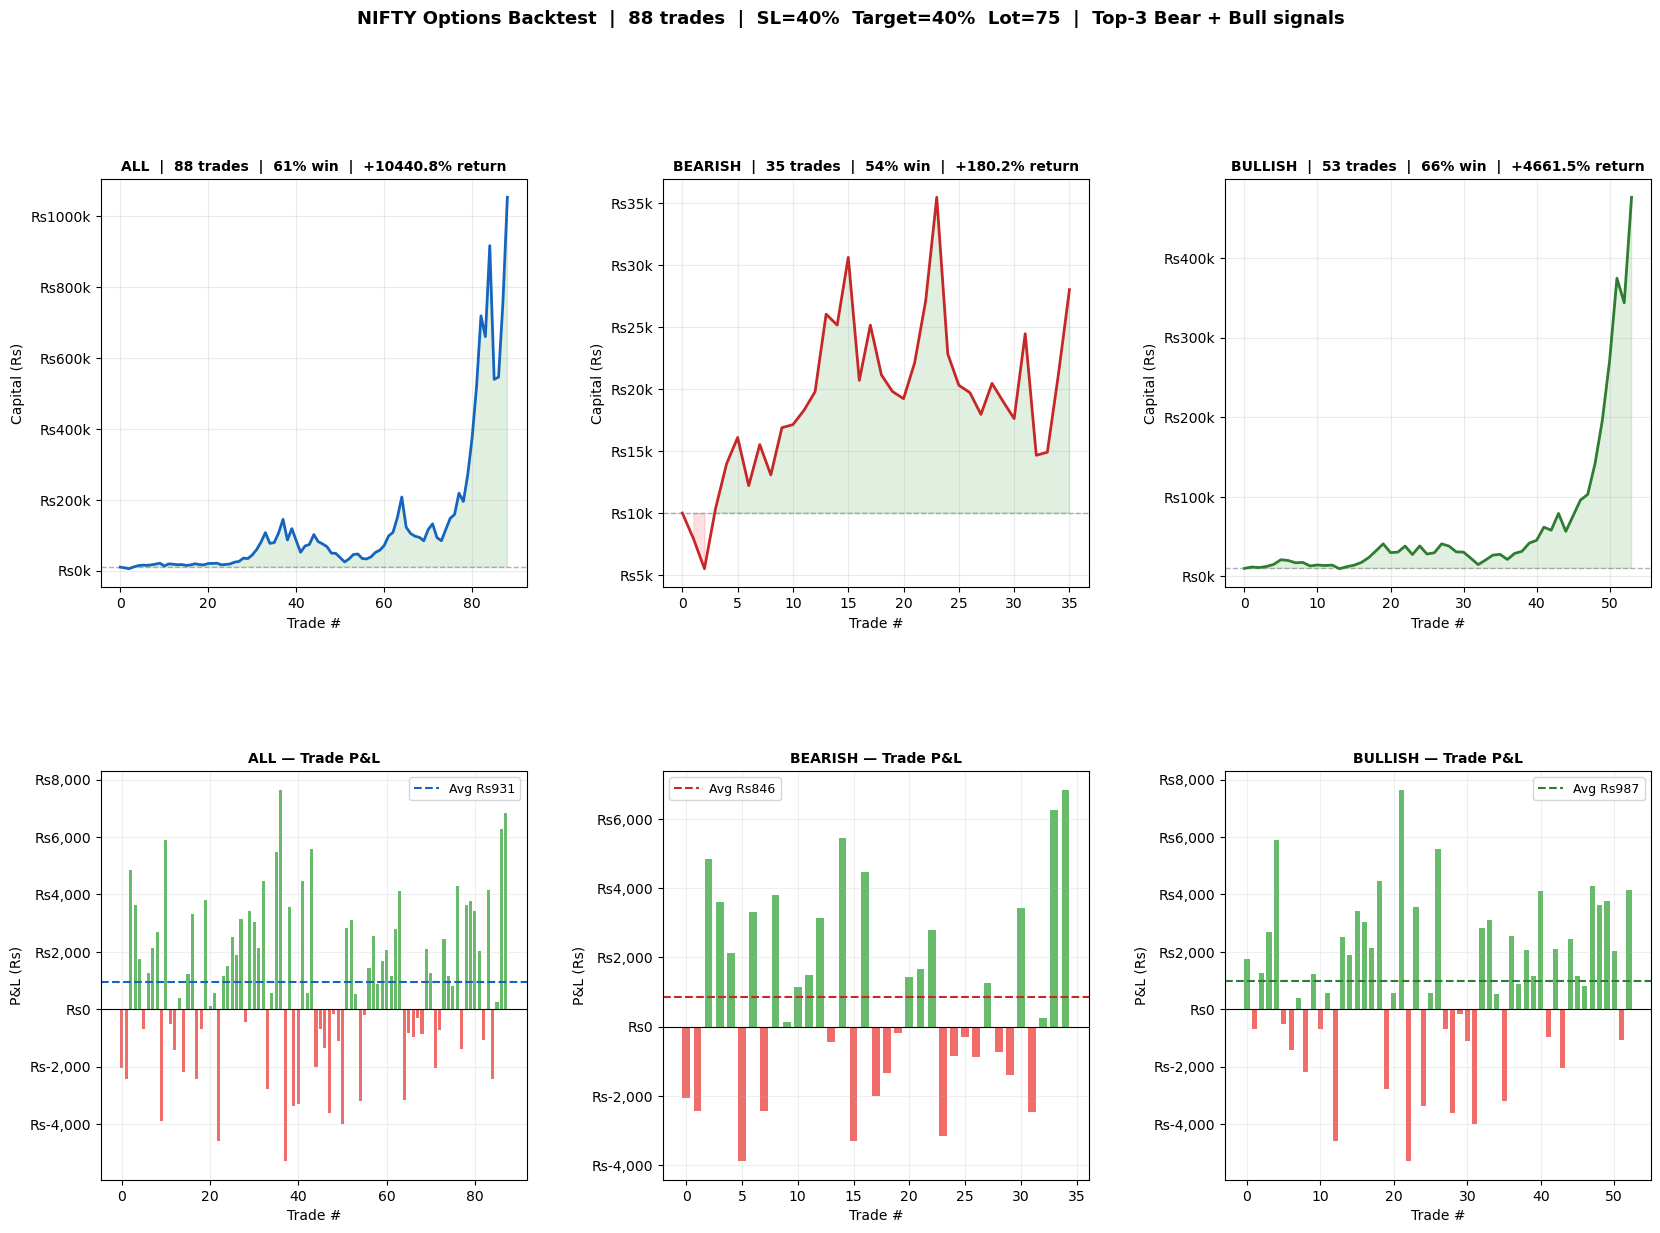

Chart saved: backtest_results.png


In [27]:
# ── Cell 9: Charts ─────────────────────────────────────────────────────────────
if len(results_df) == 0:
    print('No trades to chart.')
else:
    fig = plt.figure(figsize=(20, 13))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.32)
    clr = {'ALL': '#1565C0', 'BEARISH': '#C62828', 'BULLISH': '#2E7D32'}

    subsets = {
        'ALL'     : results_df,
        'BEARISH' : results_df[results_df['Signal'] == 'BEARISH'],
        'BULLISH' : results_df[results_df['Signal'] == 'BULLISH'],
    }

    # Row 0: compounded equity curves
    for col_i, (key, color) in enumerate(clr.items()):
        ax  = fig.add_subplot(gs[0, col_i])
        cap = curves.get(key, [STARTING_CAPITAL])
        sub = subsets[key]
        n   = len(sub)
        wr  = (sub['P&L (Rs)'] > 0).mean() * 100 if n > 0 else 0
        ret = (cap[-1] - STARTING_CAPITAL) / STARTING_CAPITAL * 100 if len(cap) > 1 else 0

        ax.plot(cap, color=color, linewidth=2, zorder=3)
        ax.axhline(STARTING_CAPITAL, color='gray', linestyle='--', linewidth=1, alpha=0.6)
        xs = range(len(cap))
        ax.fill_between(xs, STARTING_CAPITAL, cap,
                        where=[c >= STARTING_CAPITAL for c in cap],
                        color='green', alpha=0.12)
        ax.fill_between(xs, STARTING_CAPITAL, cap,
                        where=[c <  STARTING_CAPITAL for c in cap],
                        color='red',   alpha=0.12)
        ax.set_title(f'{key}  |  {n} trades  |  {wr:.0f}% win  |  {ret:+.1f}% return',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Trade #')
        ax.set_ylabel('Capital (Rs)')
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'Rs{x/1000:.0f}k'))
        ax.grid(alpha=0.25)

    # Row 1: per-trade P&L bar charts
    for col_i, (key, color) in enumerate(clr.items()):
        ax  = fig.add_subplot(gs[1, col_i])
        sub = subsets[key]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No trades', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_title(f'{key} — P&L per trade', fontsize=10)
            continue

        pnl  = sub['P&L (Rs)'].values
        bclr = ['#4CAF50' if p > 0 else '#EF5350' for p in pnl]
        ax.bar(range(len(pnl)), pnl, color=bclr, alpha=0.85, width=0.7)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(pnl.mean(), color=color, linewidth=1.5,
                   linestyle='--', label=f'Avg Rs{pnl.mean():,.0f}')
        ax.set_title(f'{key} — Trade P&L', fontsize=10, fontweight='bold')
        ax.set_xlabel('Trade #')
        ax.set_ylabel('P&L (Rs)')
        ax.legend(fontsize=9)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'Rs{x:,.0f}'))
        ax.grid(alpha=0.2)

    title = (f'NIFTY Options Backtest  |  {len(results_df)} trades  |  '
             f'SL={STOP_LOSS_PCT:.0%}  Target={PROFIT_TARGET_PCT:.0%}  '
             f'Lot={LOT_SIZE}  |  Top-3 Bear + Bull signals')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(OUT_DIR / 'backtest_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved: backtest_results.png')